In [1]:
from lab1.src.fetch.arxiv_fetcher import ArxivFetcher
from lab1.src.graph.cluster_graph import ClusterGraph
from lab1.src.graph.links_graph import LinksGraph
from lab1.src.graph.publications_graph import PublicationsGraph
from lab1.src.keyword.keyword_scoring_processor import KeywordScoringProcessor
from lab1.src.pages.pages_processor import PagesProcessor
from lab1.src.save.json_saver import save_to_json
from lab1.src.fetch.json_fetcher import fetch_from_json
from lab1.src.constant.arxiv import CATEGORY

## №1 Выбрать тематику научных публикаций, любую область знаний, например, machine learning или artificial intelligence.

In [2]:
print(f"категория {CATEGORY}")

категория eess.IV


## №2 Скачать с https://arxiv.org/ данные о научных публикациях по выбранной тематике. Выгрузить названия, авторов и аннотации статей. Скачивать через api https://info.arxiv.org/help/api/user-manual.html. Не менее 250 публикаций.

In [3]:
need_to_download_pages = False
fetcher = ArxivFetcher()

pages = None
if need_to_download_pages:
    pages = fetcher.fetch_arxiv_pages_or_get_cashed()
    save_to_json(pages)
else:
    pages = fetch_from_json()

In [4]:
page_processor = PagesProcessor(pages)

## №3 Выделить ключевые слова по каждой публикации (используйте названия и аннотации).

In [5]:
page_processor.show_pages_with_keywords_count()

Найдено 45 статьи/ей с ключевыми словами


In [6]:
page_processor.get_samples()

,title,authors,summary,keywords
106,Cross-Modality Distillation: A case for Condit...,"[Siddharth Roheda, Benjamin S. Riggan, Hamid K...","In this paper, we propose to use a Conditional...",None
103,Fringe pattern analysis using deep learning,"[Shijie Feng, Qian Chen, Guohua Gu, Tianyang T...","In many optical metrology techniques, fringe p...",None
52,3D Video Quality Metric for 3D Video Compression,"[Amin Banitalebi-Dehkordi, Mahsa T. Pourazad, ...",As the evolution of multiview display technolo...,None
200,An Interactive LiDAR to Camera Calibration,"[Yecheng Lyu, Lin Bai, Mahdi Elhousni, Xinming...",Recent progress in the automated driving syste...,None
26,Polyp Segmentation in Colonoscopy Images Using...,"[Mojtaba Akbari, Majid Mohrekesh, Ebrahim Nasr...",Colorectal cancer is a one of the highest caus...,None
166,2.5D Deep Learning for CT Image Reconstruction...,"[Amirkoushyar Ziabari, Dong Hye Ye, Somesh Sri...",While Model Based Iterative Reconstruction (MB...,None
136,Fusion of Urban TanDEM-X raw DEMs using variat...,"[Hossein Bagheri, Michael Schmitt, Xiao Xiang ...","Recently, a new global Digital Elevation Model...",None
38,Nonlinear Shape Regression For Filtering Segme...,"[Jie Wang, Zhongxiao Fu, Nasrin Sadeghzadehyaz...",A shape filter is presented to repair segmenta...,None
79,Global Ultrasound Elastography Using Convoluti...,"[Md. Golam Kibria, Hassan Rivaz]",Displacement estimation is very important in u...,None
226,Perceptual Quality Study on Deep Learning base...,"[Zhengxue Cheng, Pinar Akyazi, Heming Sun, Jir...",Recently deep learning based image compression...,None


In [7]:
page_processor.update_keywords()

In [8]:
page_processor.get_samples()

,title,authors,summary,keywords
165,Fast and Accurate Depth Estimation from Sparse...,"[Aleksandra Chuchvara, Attila Barsi, Atanas Go...",We present a fast and accurate method for dens...,"[light fields, accurate method, sparsely sampl..."
158,A Low-rank Tensor Dictionary Learning Method f...,"[Xiao Gong, Wei Chen]","As a 3-order tensor, a multi-spectral image (M...","[images denoising, dozens of spectral bands, l..."
58,Benchmark 3D eye-tracking dataset for visual s...,"[Amin Banitalebi-Dehkordi, Eleni Nasiopoulos, ...",Visual Attention Models (VAMs) predict the loc...,"[saliency prediction, video saliency predictio..."
23,Object-based Multipass InSAR via Robust Low Ra...,"[Jian Kang, Yuanyuan Wang, Michael Schmitt, Xi...",The most unique advantage of multipass SAR int...,"[unique advantage, robust multipass insar tech..."
242,Low Photon Budget Phase Retrieval with Percept...,"[Mo Deng, Alexandre Goy, Shuai Li, Kwabena Art...",Deep neural networks (DNNs) are efficient solv...,"[neural networks deep neural, classical optimi..."
240,Modeling Generalized Rate-Distortion Functions,"[Zhengfang Duanmu, Wentao Liu, Zhou Wang]",Many multimedia applications require precise u...,"[relating visual quality, media attributes, ge..."
30,Determining JPEG Image Standard Quality Factor...,[Rémi Cogranne],Identifying the quality factor of JPEG images ...,"[jpeg image standard, identifying the quality ..."
132,Implementation of Digital Image Processing and...,"[Andrian Wijayono, Irwan, Valentinus Galih Vid...",One of the big challenges of the industry toda...,"[produce quality products, computation technol..."
176,Long Short-Term Memory Spatial Transformer Net...,"[Shiyang Feng, Tianyue Chen, Hao Sun]",Spatial transformer network has been used in a...,"[network spatial transformer, memory spatial t..."
80,"Comments on ""Compression of 3D Point Clouds Us...","[Gustavo Sandri, Ricado L. de Queiroz, Philip ...",The recently introduced coder based on region-...,"[region-adaptive, recently introduced coder, c..."


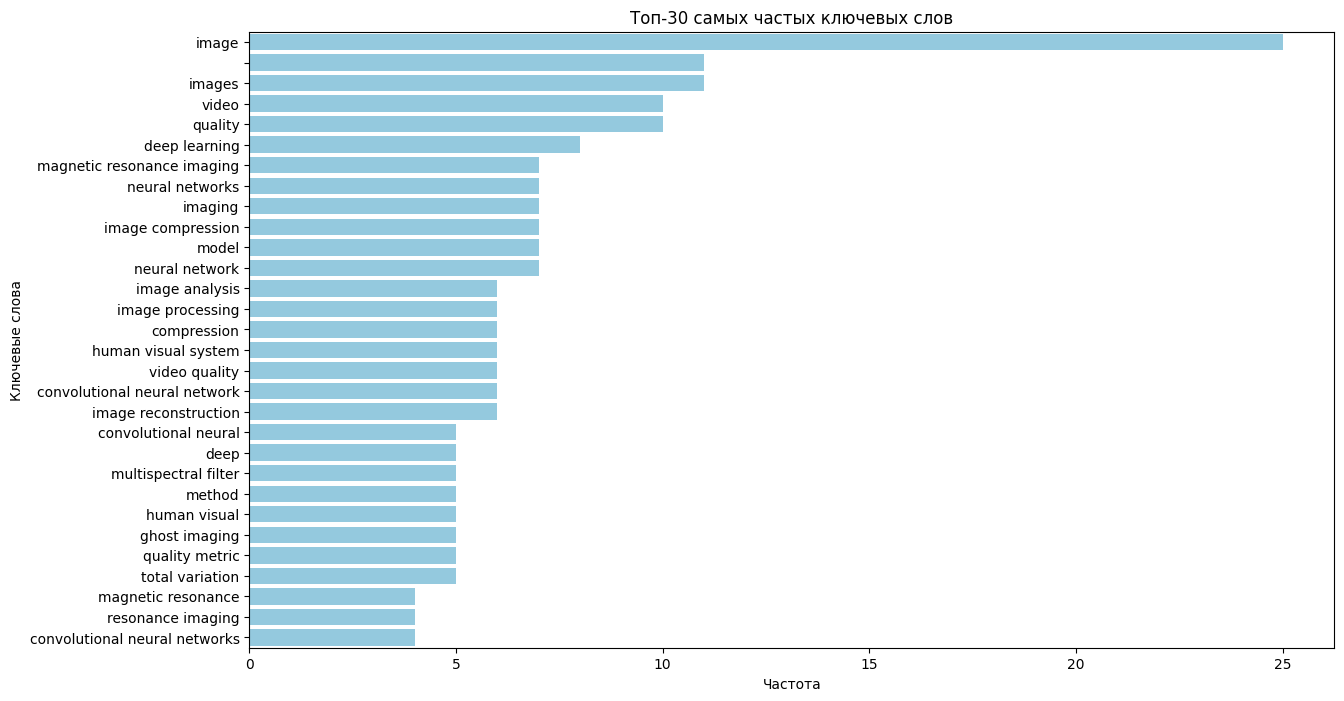

In [9]:
page_processor.show_most_common_keywords()

## №4 Построить связи между ключевыми словами на основе их принадлежности публикациям с использованием библиотеки https://networkx.org/ (как альтернативный вариант можно посмотреть https://graph-tool.skewed.de/static/doc/index.html, https://cosmograph.app/docs/cosmograph/Cosmograph%20Python/configuration/)

In [10]:
links_graph = LinksGraph(page_processor)

In [11]:
links_graph.show()

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

## №5. Определить кластеры ключевых слов на графе. Оценить качество кластеризации (например, по модулярности). Интерпретировать результат.

In [12]:
cluster_graph = ClusterGraph(links_graph.edges, links_graph.vertices)

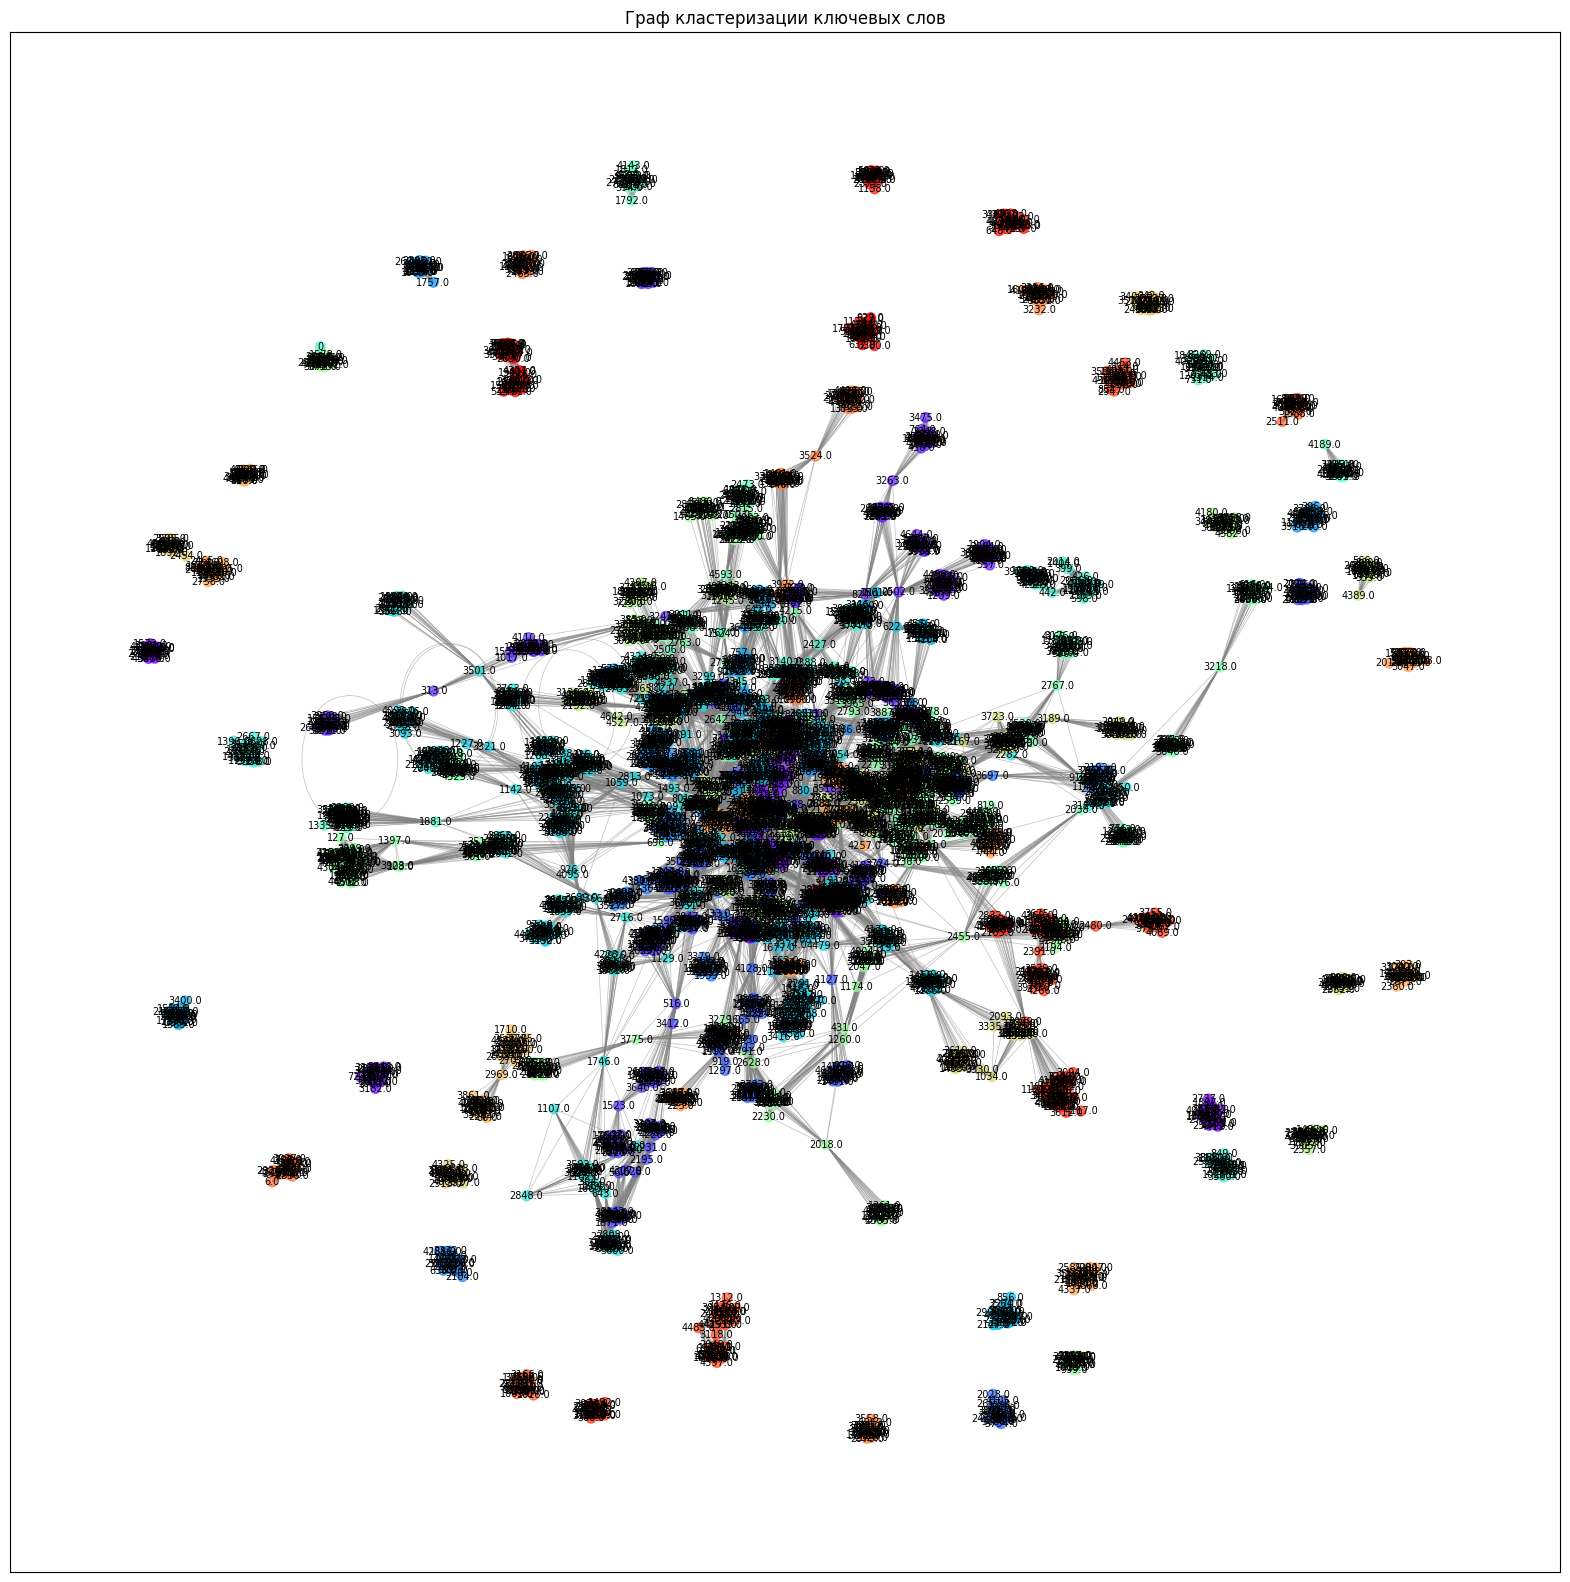

In [13]:
cluster_graph.show()

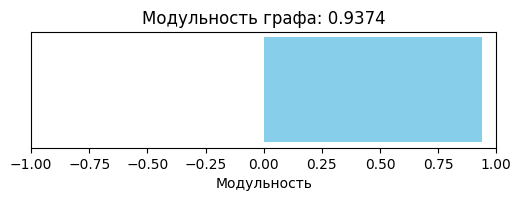

Информация о кластерах
Кластер: 44
Некоторые ключевые слова: Assessing Visual Quality of Omnidirectional Videos...
Кластер: 2
Некоторые ключевые слова: Image Acquisition System Using On Sensor Compressed Sampling Technique...
Кластер: 3
Некоторые ключевые слова: Neuromorphic adaptive edge-preserving denoising filter...
Кластер: 4
Некоторые ключевые слова: Statistically Segregated k-Space Sampling for Accelerating
  Multiple-Acquisition MRI...
Кластер: 5
Некоторые ключевые слова: Statistically Segregated k-Space Sampling for Accelerating
  Multiple-Acquisition MRI...
Кластер: 7
Некоторые ключевые слова: Light Field Retargeting for Multi-Panel Displays...
Кластер: 8
Некоторые ключевые слова: A Semi-Automated Technique for Internal Jugular Vein Segmentation in
  Ultrasound Images Using Active Contours...
Кластер: 26
Некоторые ключевые слова: Silver Standard Masks for Data Augmentation Applied to
  Deep-Learning-Based Skull-Stripping...
Кластер: 10
Некоторые ключевые слова: Silver Standard

In [14]:
cluster_graph.show_info()

## №6. Найти ключевые слова с наибольшими значениями центральности в выбранной тематике (например, degree centrality, betweenness centrality, eigenvector centrality, closeness centrality). Интерпретировать результаты.

In [15]:
keyword_scoring_processor = KeywordScoringProcessor(cluster_graph)

In [16]:
keyword_scoring_processor.show_scoring_results()

Топ 5 наборов ключевых слов по degree centrality:
Image Acquisition System Using On Sensor Compressed Sampling Technique: 0.0948
Learning Based Segmentation of CT Brain Images: Application to
  Post-Operative Hydrocephalic Scans: 0.0436
Assessing Visual Quality of Omnidirectional Videos: 0.0408
Exploiting Occlusion in Non-Line-of-Sight Active Imaging: 0.0343
Predicting Encoded Picture Quality in Two Steps is a Better Way: 0.0343




Топ 5 наборов ключевых слов по closeness centrality:
Image Acquisition System Using On Sensor Compressed Sampling Technique: 0.2946
Optimal Physical Preprocessing for Example-Based Super-Resolution: 0.2557
Learning Based Segmentation of CT Brain Images: Application to
  Post-Operative Hydrocephalic Scans: 0.2467
Polyp Segmentation in Colonoscopy Images Using Fully Convolutional
  Network: 0.2465
Mosaicked multispectral image compression based on inter- and intra-band
  correlation: 0.2453




Топ 5 наборов ключевых слов по eigenvector centrality:
Image Acqu

## №7. Построить граф публикаций: если ключевое слово является тегом для двух публикаций, значит, между ними связь есть. Чем больше общих ключевых слов, тем сильнее связь (выше вес ребра). Реализовать поиск наиболее близких к заданной пользователем публикаций на графе.

In [17]:
publications_graph = PublicationsGraph(page_processor)

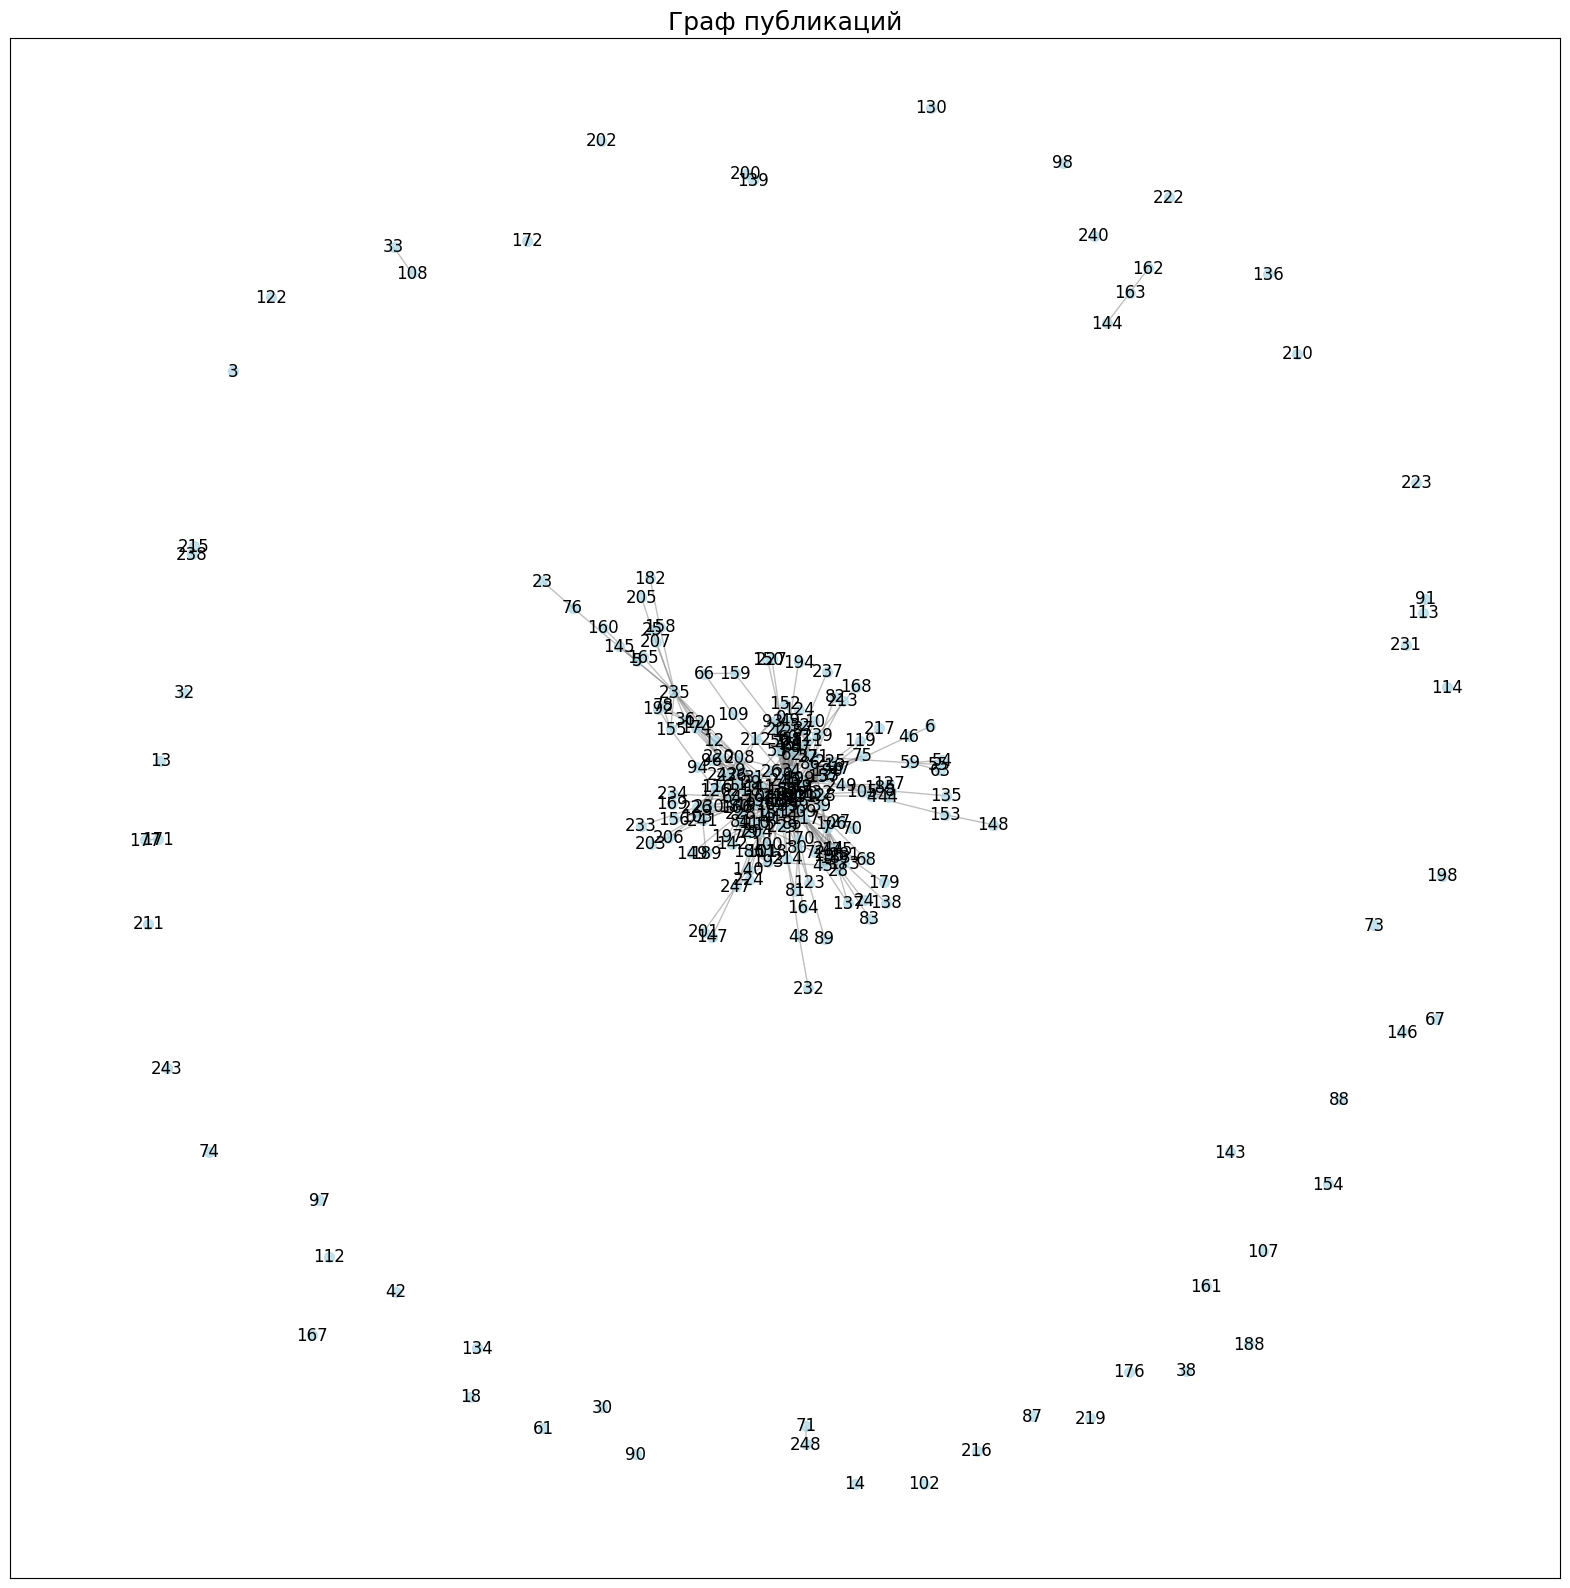

In [18]:
publications_graph.show()

In [19]:
result = publications_graph.find_neighbors(212)

print(f"Для публикации {result['publication']} с заголовком \"{result['publication_title']}\" найдены соседние публикации:")

for n, title in result["titles"]:
    print(f"  - {n}: \"{title}\"")


Для публикации 212 с заголовком "Total Variation and Tight Frame Image Segmentation with Intensity
  Inhomogeneity" найдены соседние публикации:
  - 9: "Silver Standard Masks for Data Augmentation Applied to
  Deep-Learning-Based Skull-Stripping"
  - 93: "Comparative survey: People detection, tracking and multi-sensor Fusion
  in a video sequence"
  - 116: "A Brief Survey and an Application of Semantic Image Segmentation for
  Autonomous Driving"
  - 152: "Validation of Biometric Identification of Dairy Cows based on Udder NIR
  Images"
  - 221: "Hyperspectral Unmixing via Deep Autoencoder Networks for a Generalized
  Linear-Mixture/Nonlinear-Fluctuation Model"
